In [1]:
import psutil
import multiprocessing

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, LinearRegressionModel, DecisionTreeRegressor, DecisionTreeRegressionModel, RandomForestRegressor, RandomForestRegressionModel, GBTRegressor, GBTRegressionModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

## Setup Spark Session

In [2]:
total_memory_gb = int(psutil.virtual_memory().total / (1024**3))
print(total_memory_gb)

total_cores = multiprocessing.cpu_count()
print(total_cores)

58
12


In [3]:
spark= SparkSession \
       .builder \
       .appName("DSA5208_Proj2") \
       .config("spark.driver.memory", f"{total_memory_gb}g") \
       .config("spark.driver.maxResultSize", "0") \
       .config("spark.executor.memory", f"{total_memory_gb}g") \
       .config("spark.executor.cores", str(total_cores)) \
       .getOrCreate()

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/04 12:01:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/04 12:01:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)
spark.sparkContext.getConf().getAll()

# Suppress warnings
spark.sparkContext.setLogLevel("ERROR")

Spark master: local[*]
Default parallelism: 12


In [5]:
# set seed for reproducibility
seed = 19

# Prepare Data

## Load Data 

Load the clean data saved as parquet. 

In [ ]:
dir = "2024_cleaned_data/"

# Load the Parquet data
data = spark.read.parquet(dir)

# Show a few rows
data.show(20)

+--------+---------+---------+-----+---+----+------+-------+---------+----------+------------+---------+---------+---------+
|LATITUDE|LONGITUDE|ELEVATION|MONTH|DAY|HOUR|MINUTE|WND_DIR|WND_SPEED|CIG_HEIGHT|VIS_DISTANCE|TMP_VALUE|DEW_VALUE|SLP_VALUE|
+--------+---------+---------+-----+---+----+------+-------+---------+----------+------------+---------+---------+---------+
|44.37916|-98.22275|    390.7|    1|  1|   0|    55|  300.0|     15.0|   22000.0|     16093.0|    -89.0|   -111.0|  10284.0|
|44.37916|-98.22275|    390.7|    1|  1|   1|    55|  280.0|     15.0|   22000.0|     16093.0|   -100.0|   -111.0|  10286.0|
|44.37916|-98.22275|    390.7|    1|  1|   3|    55|  230.0|     21.0|   22000.0|     16093.0|   -106.0|   -122.0|  10286.0|
|44.37916|-98.22275|    390.7|    1|  1|   6|    55|  200.0|     21.0|   22000.0|     16093.0|   -106.0|   -122.0|  10281.0|
|44.37916|-98.22275|    390.7|    1|  1|   8|    55|  140.0|     21.0|   22000.0|     16093.0|   -117.0|   -133.0|  10277.0|


In [7]:
# Verify schema 
data.printSchema()

root
 |-- LATITUDE: float (nullable = true)
 |-- LONGITUDE: float (nullable = true)
 |-- ELEVATION: float (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- HOUR: integer (nullable = true)
 |-- MINUTE: integer (nullable = true)
 |-- WND_DIR: float (nullable = true)
 |-- WND_SPEED: float (nullable = true)
 |-- CIG_HEIGHT: float (nullable = true)
 |-- VIS_DISTANCE: float (nullable = true)
 |-- TMP_VALUE: float (nullable = true)
 |-- DEW_VALUE: float (nullable = true)
 |-- SLP_VALUE: float (nullable = true)



Note that the target variable is `TMP_VALUE` while the remaining columns are feature variables (predictors). 

In [ ]:
# Verify number of rows
data.count()

18119503

We can also understand the scale of values of the target variable `TMP_VALUE`. 

+-------+------------------+
|summary|         TMP_VALUE|
+-------+------------------+
|  count|          18119503|
|   mean|131.06211699073646|
| stddev|125.53504075550659|
|    min|            -790.0|
|    max|             524.0|
+-------+------------------+



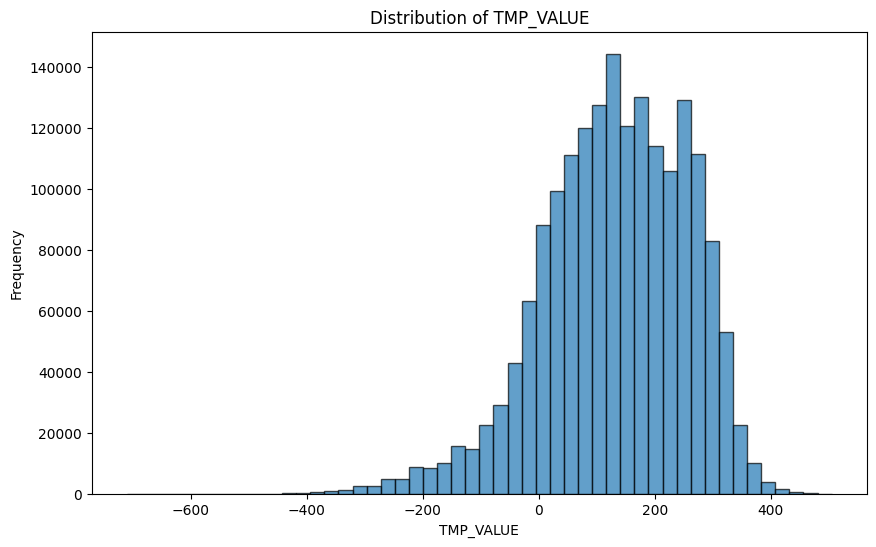

In [ ]:
import matplotlib.pyplot as plt

# Summary statistics for TMP_VALUE
data.describe("TMP_VALUE").show()

# # Sample for histogram to avoid large data
sample_data = data.sample(0.1, seed=seed).select("TMP_VALUE").toPandas()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(sample_data["TMP_VALUE"], bins=50, edgecolor='k', alpha=0.7)
plt.xlabel("TMP_VALUE")
plt.ylabel("Frequency")
plt.title("Distribution of TMP_VALUE")
plt.show()

## Split Data

We split the data into train (70%) and test (30%)

In [8]:
train_df, test_df = data.randomSplit([0.7, 0.3], seed=seed)

# # Cache for downstream stages --  didn't work due to not enough memory
# train_df.cache()
# val_df.cache()
# test_df.cache()

In [ ]:
# Check split sizes
n_train = train_df.count()
n_test = test_df.count()

print(f"Train: {n_train:}")
print(f"Test:  {n_test:}")

Train: 12684249
Test:  5435254


## Prepare Features for Training

We extract the features into a dense vector. 

In [9]:
# Define feature columns (all except TMP_VALUE)
feature_cols = [
    "LATITUDE", "LONGITUDE", "ELEVATION", "MONTH", "DAY", "HOUR", "MINUTE",
    "WND_DIR", "WND_SPEED", "CIG_HEIGHT", "VIS_DISTANCE", "DEW_VALUE", "SLP_VALUE"
]

In [10]:
# Assemble features into a vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

In [11]:
assembler.transform(train_df).show()

+---------+----------+---------+-----+---+----+------+-------+---------+----------+------------+---------+---------+---------+--------------------+
| LATITUDE| LONGITUDE|ELEVATION|MONTH|DAY|HOUR|MINUTE|WND_DIR|WND_SPEED|CIG_HEIGHT|VIS_DISTANCE|TMP_VALUE|DEW_VALUE|SLP_VALUE|            features|
+---------+----------+---------+-----+---+----+------+-------+---------+----------+------------+---------+---------+---------+--------------------+
|-64.23333|-56.716667|    208.0|    1|  1|   3|     0|  320.0|     26.0|   22000.0|     15000.0|    -19.0|    -21.0|   9909.0|[-64.233329772949...|
|-64.23333|-56.716667|    208.0|    1|  1|   4|     0|  330.0|     21.0|   22000.0|     10000.0|    -21.0|    -24.0|   9910.0|[-64.233329772949...|
|-64.23333|-56.716667|    208.0|    1|  1|   5|     0|  310.0|     15.0|   22000.0|      7000.0|    -21.0|    -27.0|   9910.0|[-64.233329772949...|
|-64.23333|-56.716667|    208.0|    1|  1|   6|     0|  180.0|     21.0|   22000.0|      9000.0|    -28.0|    -3

As we see above, all features have been extracted into a single vector in the `features` column. So, we can proceed to drop the raw feature columns. 

In [12]:
train_assembled = assembler.transform(train_df).select("features", "TMP_VALUE")

In [15]:
train_assembled.show()

+--------------------+---------+
|            features|TMP_VALUE|
+--------------------+---------+
|[-64.233329772949...|    -19.0|
|[-64.233329772949...|    -21.0|
|[-64.233329772949...|    -21.0|
|[-64.233329772949...|    -28.0|
|[-64.233329772949...|    -30.0|
|[-64.233329772949...|    -29.0|
|[-64.233329772949...|    -20.0|
|[-64.233329772949...|    -16.0|
|[-64.233329772949...|     -4.0|
|[-64.233329772949...|      1.0|
|[-64.233329772949...|     -3.0|
|[-64.233329772949...|     -1.0|
|[-64.233329772949...|     -3.0|
|[-64.233329772949...|      0.0|
|[-64.233329772949...|     -6.0|
|[-64.233329772949...|      0.0|
|[-64.233329772949...|     -9.0|
|[-64.233329772949...|    -18.0|
|[-64.233329772949...|    -21.0|
|[-64.233329772949...|    -25.0|
+--------------------+---------+
only showing top 20 rows



In [16]:
train_assembled.first()

Row(features=DenseVector([-64.2333, -56.7167, 208.0, 1.0, 1.0, 3.0, 0.0, 320.0, 26.0, 22000.0, 15000.0, -21.0, 9909.0]), TMP_VALUE=-19.0)

The same can be done for the test set

In [13]:
test_assembled = assembler.transform(test_df).select("features", "TMP_VALUE")

# Models

We try 4 models: 
1) **Linear Model**: This is the simplest model (least flexible) and hence serves as a baseline. It assumes a linear relationship between the predictors and the target.
2) **Decision Tree Regression**: A tree-based model that recursively splits the data into regions with similar target values. It can capture nonlinear relationships.
3) **Random Forest Regression:** An ensemble of many decision trees, where each tree is trained on a random subset of the data and features. The final prediction is the average of all tree predictions, which helps reduce variance and improve generalization compared to a single tree.
4) **Gradient Boosted Tree Regression**: Another ensemble method that builds trees sequentially, where each new tree tries to correct the errors made by the previous ones.

### Evaluators

For each model, the following steps are performed: 
1) Obtain performance on the default model parameters. 
2) Conduct hyperparameter tuning, where the best parameters are chosen based on the cross-validation (3-fold) score. 
3) Obtain test performance on the model with best parameters

We create the evaluators accordingly for these steps

In [14]:
# Evaluate the model
evaluator_rmse = RegressionEvaluator(
    labelCol="TMP_VALUE",
    predictionCol="prediction",
    metricName="rmse"
)

In [ ]:
model_save_path = "models/"

## Model 1: Linear Model

Since we want to experiment with elastic net for regularization, we will have to scale features. 

In [16]:
# Scaler model for feature scaling
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
scaler_model = scaler.fit(train_assembled)

# Transform the training data
train_scaled = scaler_model.transform(train_assembled).select("scaledFeatures", "TMP_VALUE")
train_scaled = train_scaled.withColumnRenamed("scaledFeatures", "features")

# Transform the test data
test_scaled = scaler_model.transform(test_assembled).select("scaledFeatures", "TMP_VALUE")
test_scaled = test_scaled.withColumnRenamed("scaledFeatures", "features")

In [ ]:
# Create simple lienar model
lr = LinearRegression(
    featuresCol="features",
    labelCol="TMP_VALUE"
)

# Fit the model on training data
lr_model = lr.fit(train_scaled)

In [18]:
# Train performance 
train_predictions = lr_model.transform(train_scaled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Training RMSE: {train_rmse:.4f}")

Training RMSE: 51.6832


In [19]:
# Test performance 
test_predictions = lr_model.transform(test_scaled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 51.6683


### Hyperparameter Tuning

In [ ]:
### WARNING: This cell may take a few minutes to run ###
# Define Linear Regression
lr_cv = LinearRegression(
    featuresCol="features",
    labelCol="TMP_VALUE"
)

# Build parameter grid
lr_param_grid = ParamGridBuilder() \
    .addGrid(lr_cv.regParam, [0.0, 0.1, 0.3, 1.0]) \
    .addGrid(lr_cv.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# Define cross-validator
lr_crossval = CrossValidator(
    estimator=lr_cv,
    estimatorParamMaps=lr_param_grid,
    evaluator=evaluator_rmse,
    numFolds=3
)

# Fit cross-validator
lr_cv_model = lr_crossval.fit(train_scaled)

# Get best LR model
best_lr_model = lr_cv_model.bestModel


# Print best parameters
best_lr_reg_param = best_lr_model.getRegParam()
best_lr_elastic_net = best_lr_model.getElasticNetParam()
print(f"Best LR params: regParam={best_lr_reg_param}, elasticNetParam={best_lr_elastic_net}")

Best LR params: regParam=0.0, elasticNetParam=0.0


### Best Model Config

In [30]:
# Retrain model with the entire training set and best parameters
lr_best = LinearRegression(
    featuresCol="features",
    labelCol="TMP_VALUE",
    regParam=best_lr_reg_param,
    elasticNetParam=best_lr_elastic_net
)

# Fit the model on entire training data (scaled)
final_lr_model = lr_best.fit(train_scaled)

In [31]:
lr_path = model_save_path + "lr_model/"

In [32]:
# Save the final linear regression model 
final_lr_model.write().overwrite().save(lr_path) 
print(f"Model saved to: {lr_path}")

Model saved to: /home/ryanltz2000/dsa5208_proj2/models/lr_model/


In [33]:
# Load the final linear regression model
final_lr_model = LinearRegressionModel.load(lr_path)

In [34]:
# Evaluate on train set
train_predictions = final_lr_model.transform(train_scaled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Train RMSE with best CV model: {train_rmse:.4f}")

Train RMSE with best CV model: 51.6832


In [35]:
# Evaluate on test set
test_predictions = final_lr_model.transform(test_scaled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE with best CV model: {test_rmse:.4f}")

Test RMSE with best CV model: 51.6683


## Model 2: Decision Trees

In [59]:
# Define Decision Tree Regressor
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE", 
    seed=seed
)

# Fit the model on training data
dt_model = dt.fit(train_assembled)

In [60]:
# Train performance 
train_predictions = dt_model.transform(train_assembled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Training RMSE: {train_rmse:.4f}")

Training RMSE: 53.7153


In [61]:
# Test performance 
test_predictions = dt_model.transform(test_assembled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 53.6902


### Hyperparameter Tuning

In [ ]:
### WARNING: This cell may take very long to run ###
# Define Decision Tree Regressor
dt_cv = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE", 
    seed=seed
)

# Build parameter grid for DT
dt_param_grid = ParamGridBuilder() \
    .addGrid(dt_cv.maxDepth, [5, 7, 10, 12]) \
    .addGrid(dt_cv.maxBins, [32, 64, 128, 256]) \
    .addGrid(dt_cv.minInfoGain, [0.0, 0.01, 0.1]) \
    .build()

# Define cross-validator for DT
dt_crossval = CrossValidator(
    estimator=dt_cv,
    estimatorParamMaps=dt_param_grid,
    evaluator=evaluator_rmse,
    numFolds=3
)

# Fit cross-validator on combined train+val
dt_cv_model = dt_crossval.fit(train_assembled)

# Get best DT model
best_dt_model = dt_cv_model.bestModel

# Print best parameters
best_dt_max_depth = best_dt_model.getMaxDepth()
best_dt_max_bins = best_dt_model.getMaxBins()
best_dt_min_info_gain = best_dt_model.getMinInfoGain()
print(f"Best DT params: maxDepth={best_dt_max_depth}, maxBins={best_dt_max_bins}, minInfoGain={best_dt_min_info_gain}")

Best DT params: maxDepth=12, maxBins=256, minInfoGain=0.0


### Best Model Config

In [ ]:
# Retrain model with the entire training set and best parameters
dt_best = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE",
    maxDepth=best_dt_max_depth,
    maxBins=best_dt_max_bins,
    minInfoGain=best_dt_min_info_gain, 
    seed=seed
)

# Fit the model on entire training data
final_dt_model = dt_best.fit(train_assembled)

In [46]:
dt_path = model_save_path + "dt_model/"

In [50]:
# Save the final decision tree model 
final_dt_model.write().overwrite().save(dt_path) 
print(f"Model saved to: {dt_path}")

Model saved to: /home/ryanltz2000/dsa5208_proj2/models/dt_model/


In [51]:
# Load the final decision tree model
final_dt_model = DecisionTreeRegressionModel.load(dt_path)

In [52]:
# Evaluate on train set
train_predictions = final_dt_model.transform(train_assembled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Train RMSE with best DT model: {train_rmse:.4f}")

Train RMSE with best DT model: 35.2695


In [53]:
# Evaluate on test set
test_predictions = final_dt_model.transform(test_assembled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE with best DT model: {test_rmse:.4f}")

Test RMSE with best DT model: 35.3651


## Model 3: Random Forest

In [56]:
# Define Decision Tree Regressor
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE", 
    seed=seed
)

# Fit the model on training data
rf_model = rf.fit(train_assembled)

In [57]:
# Train performance 
train_predictions = rf_model.transform(train_assembled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Training RMSE: {train_rmse:.4f}")

Training RMSE: 51.9314


In [58]:
# Test performance 
test_predictions = rf_model.transform(test_assembled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 51.9527


In [ ]:
### WARNING: This cell may take very long to run ###
# Define Random Forest Regressor
rf_cv = RandomForestRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE", 
    seed=seed
)

# Build parameter grid for RF
rf_param_grid = ParamGridBuilder() \
    .addGrid(rf_cv.numTrees, [2, 5, 7]) \
    .addGrid(rf_cv.maxDepth, [10, 12]) \
    .addGrid(rf_cv.maxBins, [32, 64, 128]) \
    .addGrid(rf_cv.minInfoGain, [0.]0, 0.01, 0.1) \
    .build()

# Define cross-validator for RF
rf_crossval = CrossValidator(
    estimator=rf_cv,
    estimatorParamMaps=rf_param_grid,
    evaluator=evaluator_rmse,
    numFolds=3
)

# Fit cross-validator on combined train+val
rf_cv_model = rf_crossval.fit(train_assembled)

# Get best RF model
best_rf_model = rf_cv_model.bestModel

In [ ]:
# Print best parameters
best_rf_num_trees = best_rf_model.getNumTrees
best_rf_max_depth = best_rf_model.getMaxDepth()
best_rf_max_bins = best_rf_model.getMaxBins()
best_rf_min_info_gain = best_rf_model.getMinInfoGain()
print(f"Best RF params: numTrees={best_rf_num_trees}, maxDepth={best_rf_max_depth}, maxBins={best_rf_max_bins}, minInfoGain={best_rf_min_info_gain}")

Best RF params: numTrees=7, maxDepth=12, maxBins=128, minInfoGain=0.0


### Best Model Config

In [ ]:
# Retrain model with the entire training set and best parameters
rf_best = RandomForestRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE",
    numTrees=best_rf_num_trees,
    maxDepth=best_rf_max_depth,
    maxBins=best_rf_max_bins,
    minInfoGain=best_rf_min_info_gain, 
    seed=seed
)

# Fit the model on entire training data
final_rf_model = rf_best.fit(train_assembled)

In [13]:
rf_path = model_save_path + "rf_model/"

In [64]:
# Save the final random forest model 
final_rf_model.write().overwrite().save(rf_path) 
print(f"Model saved to: {rf_path}")

Model saved to: /home/ryanltz2000/dsa5208_proj2/models/rf_model/


In [14]:
# Load the final random forest model
final_rf_model = RandomForestRegressionModel.load(rf_path)

In [68]:
# Evaluate on train set
train_predictions = final_rf_model.transform(train_assembled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Train RMSE with best RF model: {train_rmse:.4f}")

Train RMSE with best RF model: 31.9723


In [69]:
# Evaluate on test set
test_predictions =  final_rf_model.transform(test_assembled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE with best RF model: {test_rmse:.4f}")

Test RMSE with best RF model: 32.0394


## Model 4: Gradient Boosted Tree

In [70]:
# Define Gradient Boosted Tree Regressor
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE", 
    seed=seed
)
# Fit the model on training data
gbt_model = gbt.fit(train_assembled)

In [71]:
# Train performance 
train_predictions = gbt_model.transform(train_assembled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Training RMSE: {train_rmse:.4f}")

Training RMSE: 39.3515


In [72]:
# Test performance 
test_predictions = gbt_model.transform(test_assembled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 39.3632


### Hyperparameter Tuning

In [ ]:
### WARNING: This cell may take very long to run ###
# Define Gradient Boosted Tree Regressor
gbt_cv = GBTRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE", 
    maxBins = 128, 
    minInfoGain = 0, 
    seed=seed
)
# based on previous model experiments, we fix maxBins and minInfoGain

# Build parameter grid for GBT
gbt_param_grid = ParamGridBuilder() \
    .addGrid(gbt_cv.maxIter, [10, 20]) \
    .addGrid(gbt_cv.maxDepth, [10, 12]) \
    .addGrid(gbt_cv.stepSize, [0.1, 0.2, 0.3]) \
    .build()

# Define cross-validator for GBT
gbt_crossval = CrossValidator(
    estimator=gbt_cv,
    estimatorParamMaps=gbt_param_grid,
    evaluator=evaluator_rmse,
    numFolds=3
)

# Fit cross-validator on combined train+val
gbt_cv_model = gbt_crossval.fit(train_assembled)

# Get best GBT model
best_gbt_model = gbt_cv_model.bestModel

# Print best parameters
best_gbt_max_iter = best_gbt_model.getMaxIter()
best_gbt_max_depth = best_gbt_model.getMaxDepth()
best_gbt_step_size = best_gbt_model.getStepSize()
print(f"Best GBT params: maxIter={best_gbt_max_iter}, maxDepth={best_gbt_max_depth}, stepSize={best_gbt_step_size}")

Best GBT params: maxIter=20, maxDepth=12, stepSize=0.3


### Best Model Config

In [ ]:
# Retrain model with the entire training set and best parameters
gbt_best = GBTRegressor(
    featuresCol="features",
    labelCol="TMP_VALUE",
    maxBins = 128,
    minInfoGain = 0,
    maxIter=best_gbt_max_iter,
    maxDepth=best_gbt_max_depth,
    stepSize=best_gbt_step_size, 
    seed=seed
)

# Fit the model on entire training data
final_gbt_model = gbt_best.fit(train_assembled)

In [82]:
gbt_path = model_save_path + "gbt_model/"

In [83]:
# Save the final gradient boosting model 
final_gbt_model.write().overwrite().save(gbt_path) 
print(f"Model saved to: {gbt_path}")

Model saved to: /home/ryanltz2000/dsa5208_proj2/models/gbt_model/


In [84]:
# Load the final gradient boosting model
final_gbt_model = GBTRegressionModel.load(gbt_path)

In [81]:
# Evaluate on train set
train_predictions = final_gbt_model.transform(train_assembled)
train_rmse = evaluator_rmse.evaluate(train_predictions)
print(f"Train RMSE with best GBT model: {train_rmse:.4f}")

Train RMSE with best GBT model: 23.2494


In [80]:
# Evaluate on test set
test_predictions = final_gbt_model.transform(test_assembled)
test_rmse = evaluator_rmse.evaluate(test_predictions)
print(f"Test RMSE with best GBT model: {test_rmse:.4f}")

Test RMSE with best GBT model: 23.8366


## Conclusion

Model 4, Gradient Boosting Tree performs the best with a test RMSE of 23.8. 

# Analysis of Prediction Quality

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [86]:
# Compute prediction errors
test_predictions = test_predictions.withColumn("error", test_predictions.prediction - test_predictions.TMP_VALUE)

# Convert to Pandas for visualization
test_predictions_pd = test_predictions.select("TMP_VALUE", "prediction", "error").toPandas()

# Add absolute error
test_predictions_pd["abs_error"] = test_predictions_pd["error"].abs()

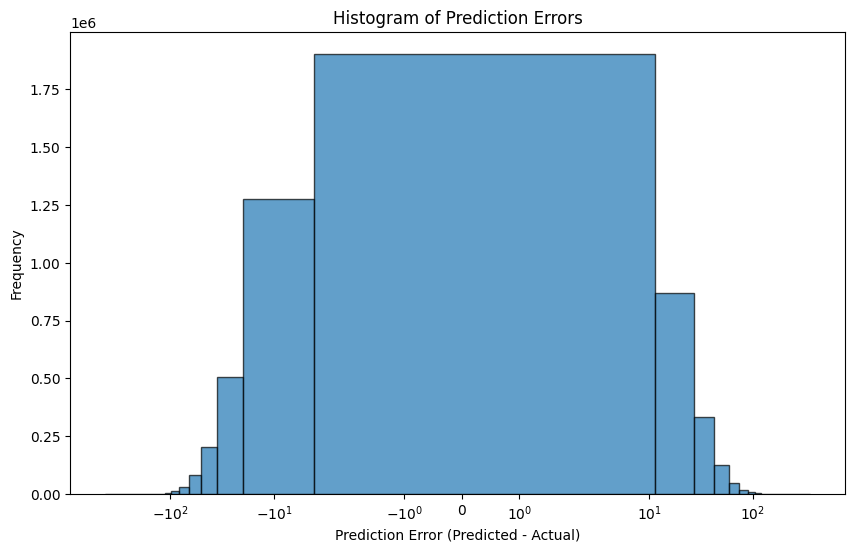

In [87]:
# Histogram of prediction errors
plt.figure(figsize=(10, 6))
plt.hist(test_predictions_pd["error"], bins=50, edgecolor='k', alpha=0.7)
# log scale x 
plt.xscale('symlog')
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Errors")
plt.show()

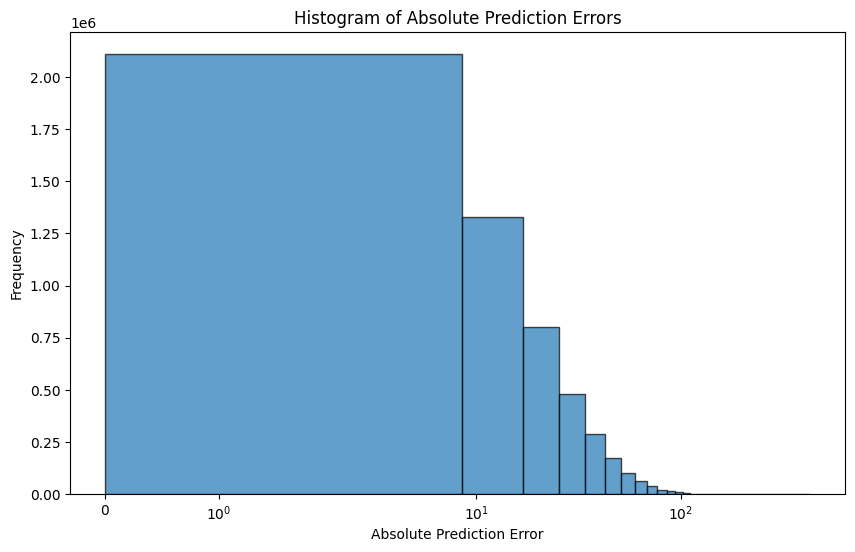

In [88]:
# Histogram of absolute errors
plt.figure(figsize=(10, 6))
plt.hist(test_predictions_pd["abs_error"], bins=50, edgecolor='k', alpha=0.7)
plt.xscale('symlog')
plt.xlabel("Absolute Prediction Error")
plt.ylabel("Frequency")
plt.title("Histogram of Absolute Prediction Errors")
plt.show()

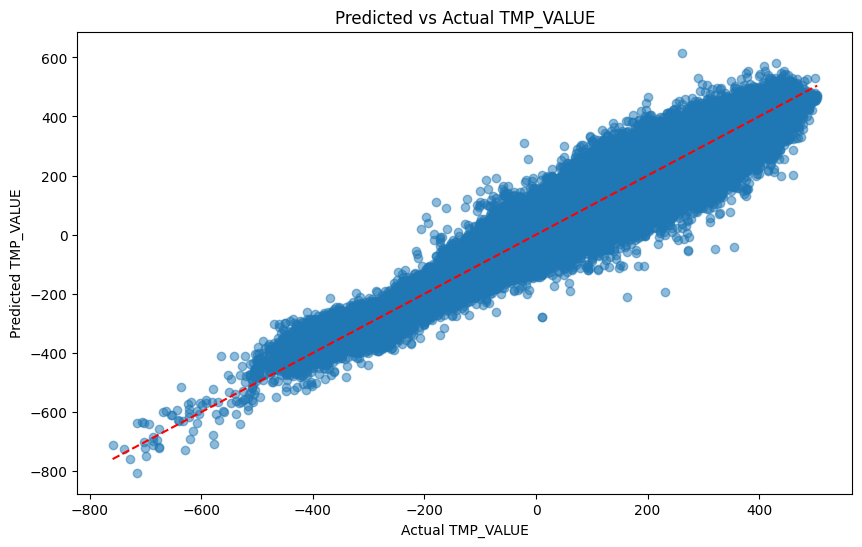

In [89]:
# Scatter plot: Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(test_predictions_pd["TMP_VALUE"], test_predictions_pd["prediction"], alpha=0.5)
plt.xlabel("Actual TMP_VALUE")
plt.ylabel("Predicted TMP_VALUE")
plt.title("Predicted vs Actual TMP_VALUE")
plt.plot([test_predictions_pd["TMP_VALUE"].min(), test_predictions_pd["TMP_VALUE"].max()], 
         [test_predictions_pd["TMP_VALUE"].min(), test_predictions_pd["TMP_VALUE"].max()], 'r--')
plt.show()

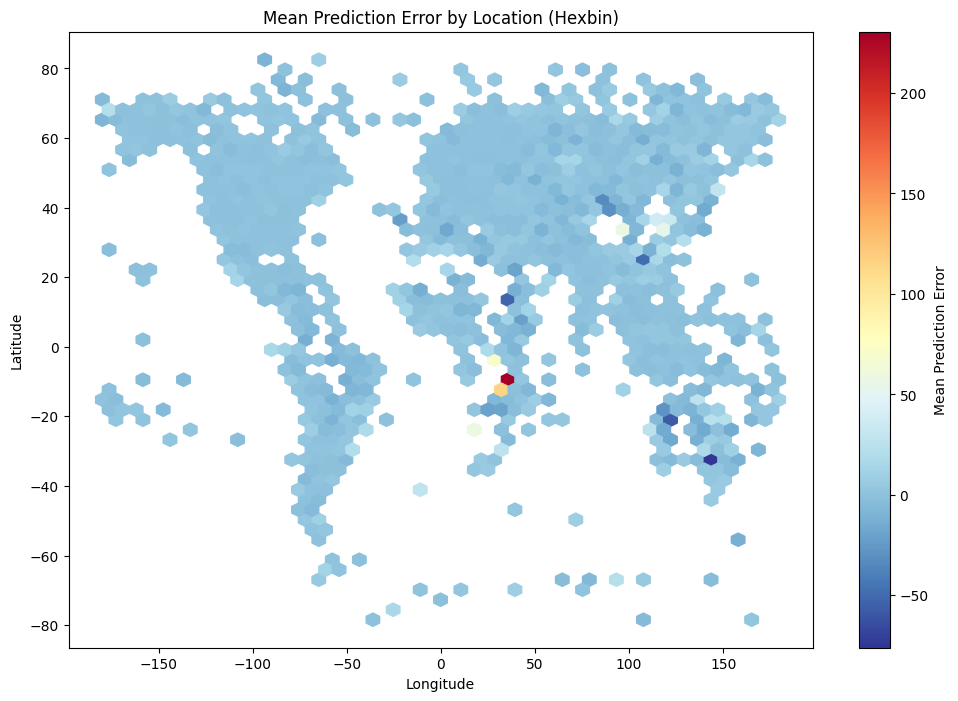

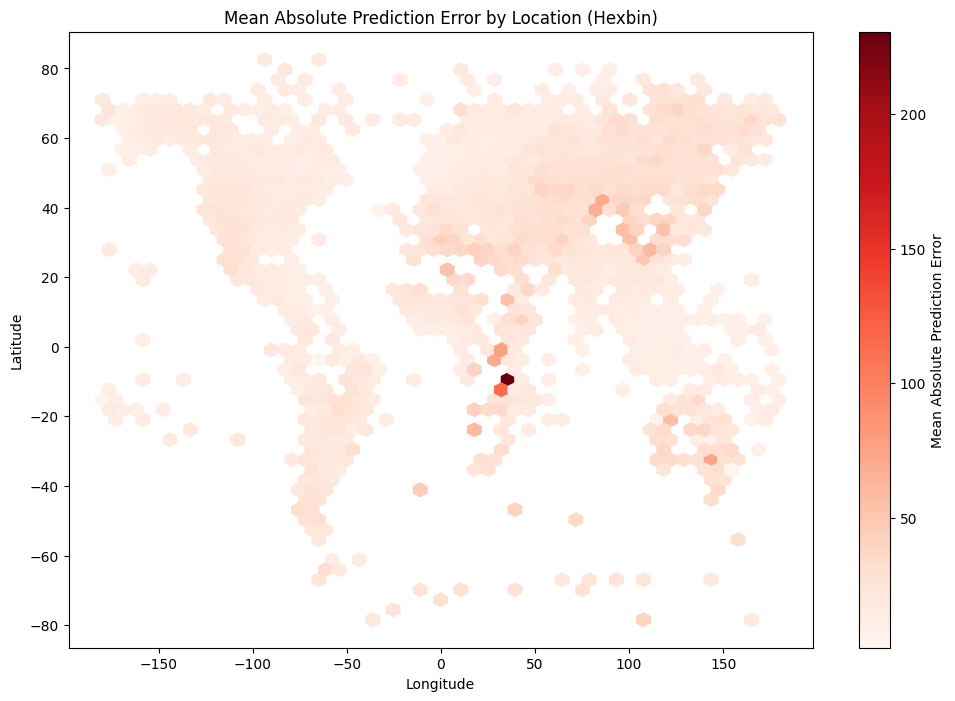

In [90]:
# Visualize prediction errors by location (latitude and longitude)
# Add latitude and longitude to the predictions DataFrame
test_loc_pd = test_df.select("LATITUDE", "LONGITUDE").toPandas()
test_predictions_pd["LATITUDE"] = test_loc_pd["LATITUDE"]
test_predictions_pd["LONGITUDE"] = test_loc_pd["LONGITUDE"]

# Hexbin plot for prediction errors (mean error per bin)
plt.figure(figsize=(12, 8))
hb = plt.hexbin(test_predictions_pd["LONGITUDE"], test_predictions_pd["LATITUDE"], C=test_predictions_pd["error"],
                gridsize=50, cmap='RdYlBu_r', reduce_C_function=np.mean, mincnt=1)
plt.colorbar(hb, label='Mean Prediction Error')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean Prediction Error by Location (Hexbin)")
plt.show()

# Hexbin plot for absolute prediction errors
plt.figure(figsize=(12, 8))
hb_abs = plt.hexbin(test_predictions_pd["LONGITUDE"], test_predictions_pd["LATITUDE"], C=test_predictions_pd["abs_error"],
                    gridsize=50, cmap='Reds', reduce_C_function=np.mean, mincnt=1)
plt.colorbar(hb_abs, label='Mean Absolute Prediction Error')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean Absolute Prediction Error by Location (Hexbin)")
plt.show()